In [1]:
## Importing libaries

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier



In [2]:
df = pd.read_csv(r"E:\SML_Project\artifacts\train_data.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group D,master's degree,standard,none,62,70,75
1,female,group C,bachelor's degree,free/reduced,completed,66,83,83
2,female,group D,some college,free/reduced,none,79,89,86
3,male,group C,master's degree,free/reduced,none,61,67,66
4,male,group E,high school,standard,none,73,64,57


In [3]:
## Checking the shape of the dataset

df.shape

(800, 8)

In [4]:
## Checking for null values

df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [5]:
## checking for duplicate values
df.duplicated().sum()


np.int64(0)

([0, 1, 2],
 [Text(0, 0, 'math score'),
  Text(1, 0, 'reading score'),
  Text(2, 0, 'writing score')])

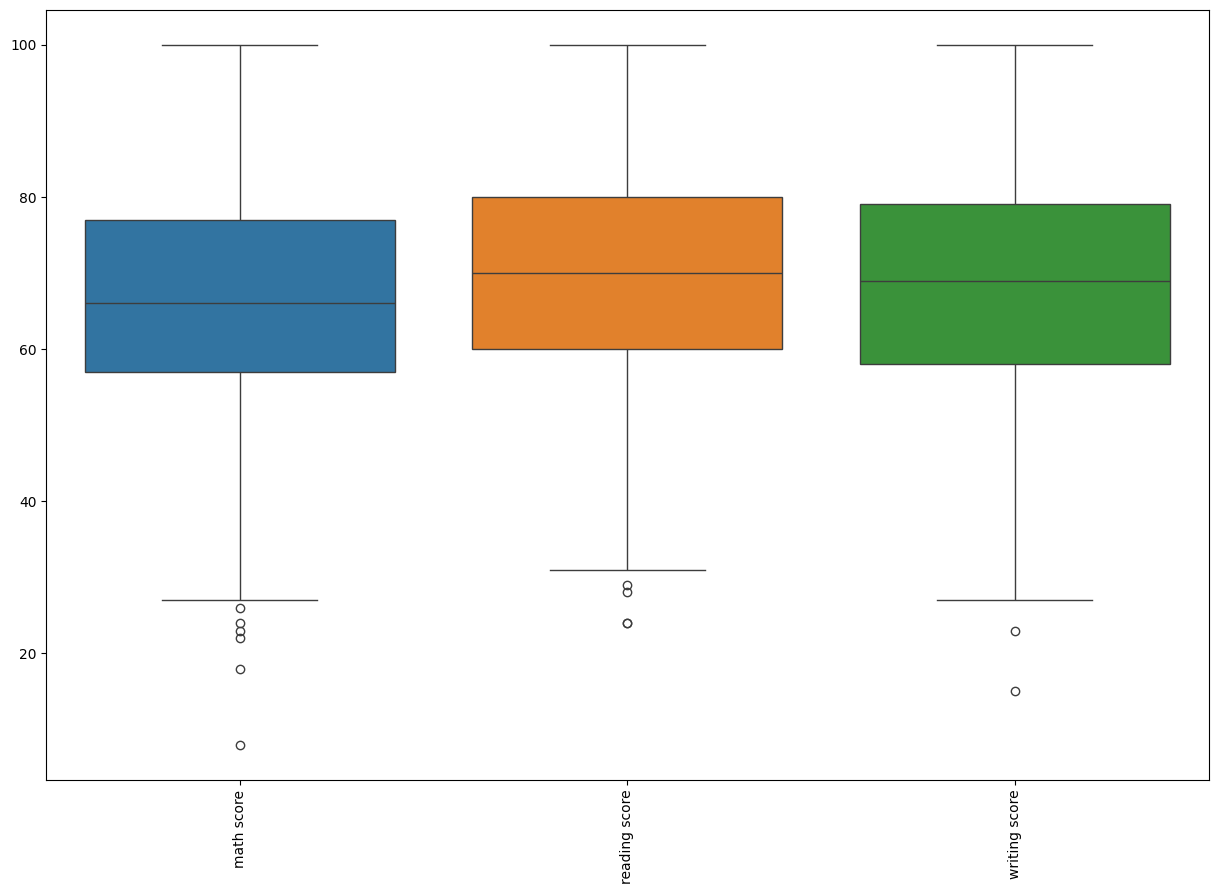

In [6]:
## checking for outliers
plt.figure(figsize=(15,10))
sns.boxplot(data=df)
plt.xticks(rotation=90)


In [7]:
## No target columns present

df["overall_score"] = df["math score"] + df["reading score"] + df["writing score"]


In [8]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,overall_score
0,female,group D,master's degree,standard,none,62,70,75,207
1,female,group C,bachelor's degree,free/reduced,completed,66,83,83,232
2,female,group D,some college,free/reduced,none,79,89,86,254
3,male,group C,master's degree,free/reduced,none,61,67,66,194
4,male,group E,high school,standard,none,73,64,57,194


In [9]:
df.gender.value_counts()

gender
female    421
male      379
Name: count, dtype: int64

In [10]:
df["race/ethnicity"].value_counts()

race/ethnicity
group C    260
group D    202
group B    153
group E    116
group A     69
Name: count, dtype: int64

In [11]:
## One hot encodeing helps to convert categorical variables into a format that can be provided to machine learning algorithms to do a better job in prediction.

cat_one = ["gender", "lunch", "test preparation course"]
ohe = OneHotEncoder( drop="first")
for  i in cat_one:
    df[i] = ohe.fit_transform(df[[i]]).toarray()
#encoded_cat_one = ohe.fit_transform(df[cat_one])

In [12]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,overall_score
0,0.0,group D,master's degree,1.0,1.0,62,70,75,207
1,0.0,group C,bachelor's degree,0.0,0.0,66,83,83,232
2,0.0,group D,some college,0.0,1.0,79,89,86,254
3,1.0,group C,master's degree,0.0,1.0,61,67,66,194
4,1.0,group E,high school,1.0,1.0,73,64,57,194


In [13]:
cat_label = ["race/ethnicity", "parental level of education"]
enco = LabelEncoder()
for i in cat_label:
    df[i] = enco.fit_transform(df[i])

In [14]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,overall_score
0,0.0,3,3,1.0,1.0,62,70,75,207
1,0.0,2,1,0.0,0.0,66,83,83,232
2,0.0,3,4,0.0,1.0,79,89,86,254
3,1.0,2,3,0.0,1.0,61,67,66,194
4,1.0,4,2,1.0,1.0,73,64,57,194


In [15]:
x = df.drop(columns=["overall_score"], )
y = df["overall_score"]



In [16]:
normal = MinMaxScaler()
x= normal.fit_transform(x)

In [17]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [18]:
## model building
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
model = LinearRegression()
model.fit(x_train, y_train)
y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)
print("R2 score for train data: ", r2_score(y_train, y_pred_train))
print("R2 score for test data: ", r2_score(y_test, y_pred_test))
print("Mean squared error for train data: ", mean_squared_error(y_train, y_pred_train))
print("Mean squared error for test data: ", mean_squared_error(y_test, y_pred_test))

R2 score for train data:  1.0
R2 score for test data:  1.0
Mean squared error for train data:  4.7003488176688765e-27
Mean squared error for test data:  4.661221316769915e-27


In [19]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
model = DecisionTreeRegressor()
model.fit(x_train, y_train)
y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)
print("R2 score for train data: ", r2_score(y_train, y_pred_train))
print("R2 score for test data: ", r2_score(y_test, y_pred_test))
print("Mean squared error for train data: ", mean_squared_error(y_train, y_pred_train))
print("Mean squared error for test data: ", mean_squared_error(y_test, y_pred_test))

R2 score for train data:  1.0
R2 score for test data:  0.9878287164018382
Mean squared error for train data:  0.0
Mean squared error for test data:  22.21875


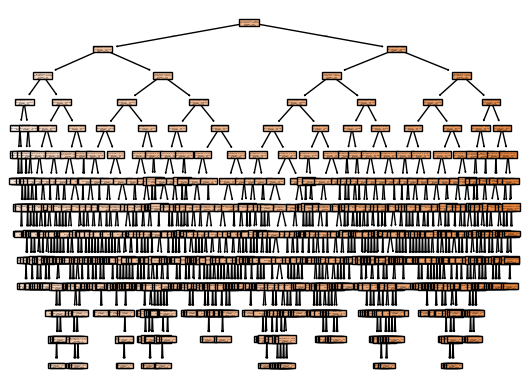

In [20]:
plot_tree(model, feature_names=df.drop(columns=["overall_score"]).columns, filled=True)
plt.show()

In [21]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
param_dist = { "ccp_alpha" : randint(0, 100),
                "min_samples_split" : randint(2, 10),
                "min_samples_leaf" : randint(1, 4),
                "max_depth" : [None, 10, 20, 30]}
dtree = DecisionTreeRegressor()
random_search = RandomizedSearchCV(estimator=dtree, param_distributions=param_dist, n_iter=10, cv=5, random_state=42)
random_search.fit(x_train, y_train)
print("Best parameters: ", random_search.best_params_)
best_model = random_search.best_estimator_
y_pred_train = best_model.predict(x_train)  
y_pred_test = best_model.predict(x_test)
print("R2 score for train data: ", r2_score(y_train, y_pred_train))
print("R2 score for test data: ", r2_score(y_test, y_pred_test))
print("Mean squared error for train data: ", mean_squared_error(y_train, y_pred_train))
print("Mean squared error for test data: ", mean_squared_error(y_test, y_pred_test))

Best parameters:  {'ccp_alpha': 1, 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2}
R2 score for train data:  0.9856458687452252
R2 score for test data:  0.9742883268267855
Mean squared error for train data:  25.614620296190417
Mean squared error for test data:  46.93681103640031


In [22]:
# Best parameters:  {'ccp_alpha': 0.1, 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2}
dtree_final = DecisionTreeRegressor(ccp_alpha=0.1, max_depth=30, min_samples_leaf=1, min_samples_split=2)
dtree_final.fit(x_train, y_train)
y_pred_train = dtree_final.predict(x_train)
y_pred_final = dtree_final.predict(x_test)
print("R2 score for train data: ", r2_score(y_train, y_pred_train))
print("R2 score for test data: ", r2_score(y_test, y_pred_final))
print("Mean squared error for train data: ", mean_squared_error(y_train, y_pred_train))
print("Mean squared error for test data: ", mean_squared_error(y_test, y_pred_final))

R2 score for train data:  0.9966950560952091
R2 score for test data:  0.9836532570738377
Mean squared error for train data:  5.897597125097125
Mean squared error for test data:  29.841075631950737


In [ ]:
from skleran.metrices import 